In [1]:
# Assignment 1: Feature Extraction via Dimensionality Reduction using Autoencoders



### Group Members Name with Student ID:
1. 2024aa05969 - MANCHI RENUKA - 100% 
2. 2024aa05014 - GITBASHYAN R  - 100%
3. 2024aa05226 - KRISHNA V     - 100%
4. 2024aa05627 - SWAMINATHAN R - 100%
5. 2024aa05677 - SRINIVASAN D  - 100%

# Assignment 1: Feature Extraction via Dimensionality Reduction using Autoencoders

## Overview
This assignment explores dimensionality reduction techniques using Principal Component Analysis (PCA) and various autoencoder architectures on the CIFAR10 and MNIST datasets. We will implement standard PCA, randomized PCA, single-layer autoencoders, deep convolutional autoencoders, and an MLP classifier for 7-segment LED digit representation.

### Dataset Information
- **CIFAR10**          : Images converted to grayscale (32x32 pixels)
- **Train/Test Split** : 70% training, 30% validation/test
- **MNIST**            : Standard 28x28 pixel grayscale images

In [2]:
# Import Required Libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.utils.extmath import randomized_svd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, confusion_matrix, roc_auc_score, classification_report
from sklearn.multiclass import OneVsRestClassifier
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, regularizers
from tensorflow.keras.datasets import cifar10, mnist
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("All libraries imported successfully!")

All libraries imported successfully!


## Task 1: PCA and Logistic Regression Classification

### Load and Preprocess CIFAR10 Dataset

In [3]:
# 1.1 Load CIFAR10 Dataset
(X_train_full, y_train_full), (X_test_full, y_test_full) = cifar10.load_data()
X_train_full = X_train_full.squeeze() / 255.0
X_test_full = X_test_full.squeeze() / 255.0

# 1.2 Convert to grayscale
def to_grayscale(images):
    """Convert RGB images to grayscale"""
    if len(images.shape) == 4:  # RGB images
        return np.dot(images[..., :3], [0.299, 0.587, 0.114])
    return images

# 1.3 Train and Test dataset
X_train_full = to_grayscale(X_train_full)
X_test_full = to_grayscale(X_test_full)
y_train_full = y_train_full.flatten()
y_test_full = y_test_full.flatten()

print(f"CIFAR10 Dataset loaded")
print(f"Training images shape: {X_train_full.shape}")
print(f"Test images shape: {X_test_full.shape}")

# 1.4 Create 70-30 split for training and validation/test
total_train_samples = len(X_train_full)
split_idx = int(0.7 * total_train_samples)

# 1.5 Randomly shuffle and split
random_indices = np.random.permutation(total_train_samples)
train_indices = random_indices[:split_idx]
val_indices = random_indices[split_idx:]


X_train = X_train_full[train_indices]
y_train = y_train_full[train_indices]
X_val = X_train_full[val_indices]
y_val = y_train_full[val_indices]

print(f"\nData Split:")
print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test_full.shape}")

# Flatten images for PCA
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test_full.reshape(X_test_full.shape[0], -1)

# Normalize data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_val_scaled = scaler.transform(X_val_flat)
X_test_scaled = scaler.transform(X_test_flat)

print(f"\nData normalized")
print(f"Training set scaled: {X_train_scaled.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 22s 0us/step
CIFAR10 Dataset loaded
Training images shape: (50000, 32, 32)
Test images shape: (10000, 32, 32)

Data Split:
Training set: (35000, 32, 32)
Validation set: (15000, 32, 32)
Test set: (10000, 32, 32)

Data normalized
Training set scaled: (35000, 1024)


In [4]:
# Task 1a: Standard PCA with 95% energy retention
print("=" * 60)
print("TASK 1A: STANDARD PCA")
print("=" * 60)

# Perform PCA to retain 95% of energy
pca_standard = PCA(n_components=0.95)
X_train_pca_standard = pca_standard.fit_transform(X_train_scaled)

# Get number of components for 95% energy
K = pca_standard.n_components_
print(f"\nNumber of components for 95% energy retention: {K}")
print(f"Explained variance ratio sum: {pca_standard.explained_variance_ratio_.sum():.4f}")
print(f"Original features: {X_train_scaled.shape[1]}, Reduced features: {K}")

# Transform validation and test data
X_val_pca_standard = pca_standard.transform(X_val_scaled)
X_test_pca_standard = pca_standard.transform(X_test_scaled)

# Train Logistic Regression classifier
print("\nTraining Logistic Regression with Standard PCA features...")
lr_standard = LogisticRegression(max_iter=1000, multi_class='multinomial', random_state=42, n_jobs=-1)
lr_standard.fit(X_train_pca_standard, y_train)

# Predict on test set
y_test_pred_standard = lr_standard.predict(X_test_pca_standard)
y_test_proba_standard = lr_standard.predict_proba(X_test_pca_standard)

# Calculate accuracy
accuracy_standard = np.mean(y_test_pred_standard == y_test_full)
print(f"Standard PCA + Logistic Regression Accuracy: {accuracy_standard:.4f}")

# Store eigenvectors for later comparison
eigenvectors_standard = pca_standard.components_

TASK 1A: STANDARD PCA

Number of components for 95% energy retention: 162
Explained variance ratio sum: 0.9501
Original features: 1024, Reduced features: 162

Training Logistic Regression with Standard PCA features...
Standard PCA + Logistic Regression Accuracy: 0.3007



Generating ROC Curve for Standard PCA...


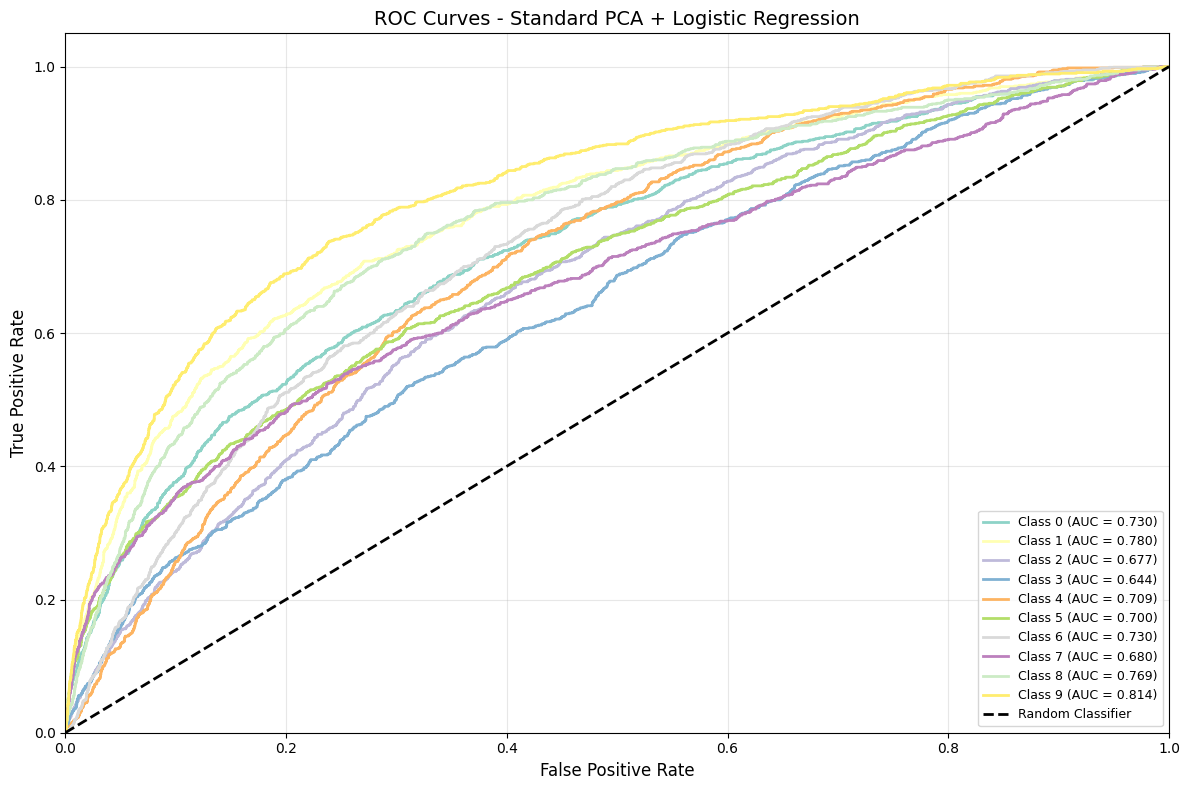

Macro-average AUC (Standard PCA): 0.7233


In [5]:
# Plot ROC Curve for Standard PCA
from sklearn.preprocessing import label_binarize

print("\nGenerating ROC Curve for Standard PCA...")

# Binarize the output for multi-class ROC
y_test_bin = label_binarize(y_test_full, classes=np.arange(10))

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(10):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_test_proba_standard[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(12, 8))
colors = plt.cm.Set3(np.linspace(0, 1, 10))

for i, color in zip(range(10), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, 
             label=f'Class {i} (AUC = {roc_auc[i]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Standard PCA + Logistic Regression', fontsize=14)
plt.legend(loc="lower right", fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate macro-average AUC
macro_auc_standard = np.mean(list(roc_auc.values()))
print(f"Macro-average AUC (Standard PCA): {macro_auc_standard:.4f}")

In [6]:
# Task 1b: Randomized PCA with same K components
print("\n" + "=" * 60)
print("TASK 1B: RANDOMIZED PCA")
print("=" * 60)

# Apply Randomized PCA with same K components (using modern PCA with random_state)
pca_randomized = PCA(n_components=K, random_state=42, svd_solver='randomized')
X_train_pca_randomized = pca_randomized.fit_transform(X_train_scaled)

# Transform validation and test data
X_val_pca_randomized = pca_randomized.transform(X_val_scaled)
X_test_pca_randomized = pca_randomized.transform(X_test_scaled)

print(f"\nRandomized PCA with {K} components")
print(f"Explained variance ratio sum: {pca_randomized.explained_variance_ratio_.sum():.4f}")

# Train Logistic Regression classifier
print("\nTraining Logistic Regression with Randomized PCA features...")
lr_randomized = LogisticRegression(max_iter=1000, multi_class='multinomial', random_state=42, n_jobs=-1)
lr_randomized.fit(X_train_pca_randomized, y_train)

# Predict on test set
y_test_pred_randomized = lr_randomized.predict(X_test_pca_randomized)
y_test_proba_randomized = lr_randomized.predict_proba(X_test_pca_randomized)

# Calculate accuracy
accuracy_randomized = np.mean(y_test_pred_randomized == y_test_full)
print(f"Randomized PCA + Logistic Regression Accuracy: {accuracy_randomized:.4f}")

# Store eigenvectors
eigenvectors_randomized = pca_randomized.components_


TASK 1B: RANDOMIZED PCA

Randomized PCA with 162 components
Explained variance ratio sum: 0.9497

Training Logistic Regression with Randomized PCA features...
Randomized PCA + Logistic Regression Accuracy: 0.3024



Generating ROC Curve for Randomized PCA...


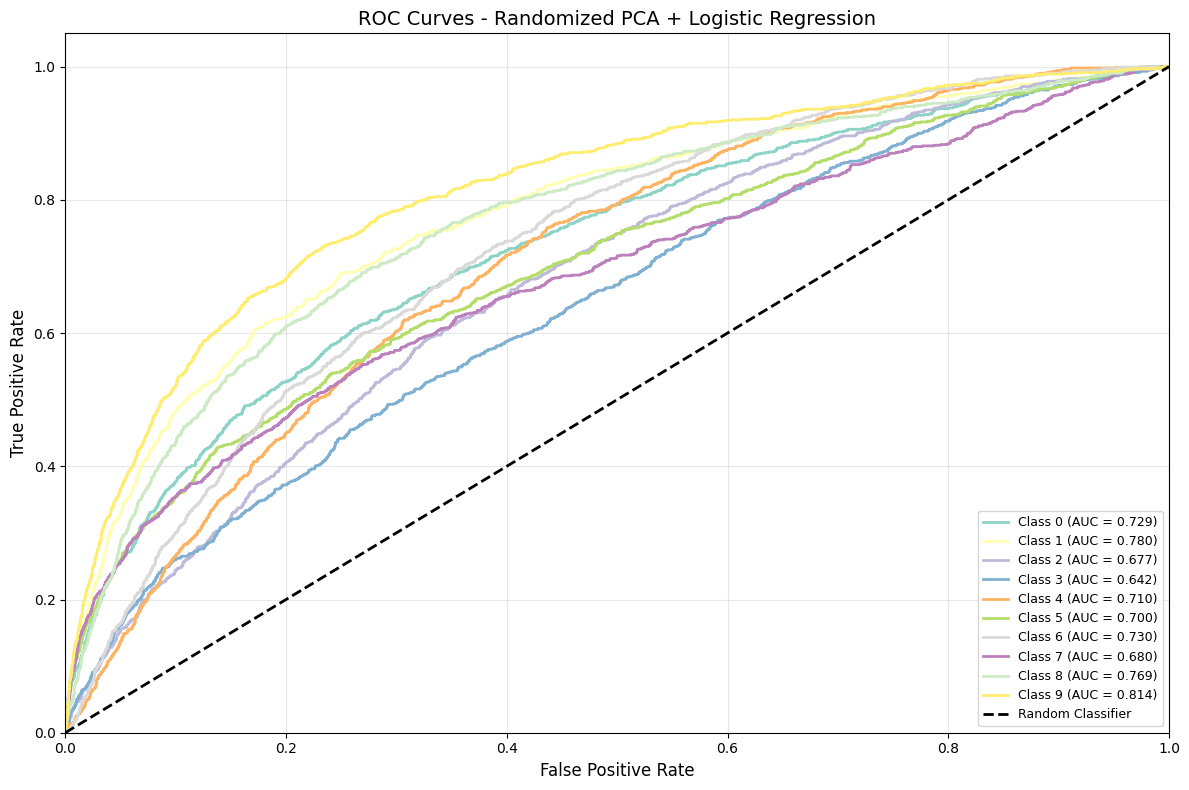

Macro-average AUC (Randomized PCA): 0.7232

PCA COMPARISON
Standard PCA Accuracy: 0.3007
Randomized PCA Accuracy: 0.3024
Standard PCA Macro-average AUC: 0.7233
Randomized PCA Macro-average AUC: 0.7232


In [7]:
# Plot ROC Curve for Randomized PCA
print("\nGenerating ROC Curve for Randomized PCA...")

# Compute ROC curve and ROC area for each class
fpr_rand = dict()
tpr_rand = dict()
roc_auc_rand = dict()

for i in range(10):
    fpr_rand[i], tpr_rand[i], _ = roc_curve(y_test_bin[:, i], y_test_proba_randomized[:, i])
    roc_auc_rand[i] = auc(fpr_rand[i], tpr_rand[i])

# Plot ROC curves
plt.figure(figsize=(12, 8))
colors = plt.cm.Set3(np.linspace(0, 1, 10))

for i, color in zip(range(10), colors):
    plt.plot(fpr_rand[i], tpr_rand[i], color=color, lw=2, 
             label=f'Class {i} (AUC = {roc_auc_rand[i]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Randomized PCA + Logistic Regression', fontsize=14)
plt.legend(loc="lower right", fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate macro-average AUC
macro_auc_randomized = np.mean(list(roc_auc_rand.values()))
print(f"Macro-average AUC (Randomized PCA): {macro_auc_randomized:.4f}")

# Comparison
print("\n" + "=" * 60)
print("PCA COMPARISON")
print("=" * 60)
print(f"Standard PCA Accuracy: {accuracy_standard:.4f}")
print(f"Randomized PCA Accuracy: {accuracy_randomized:.4f}")
print(f"Standard PCA Macro-average AUC: {macro_auc_standard:.4f}")
print(f"Randomized PCA Macro-average AUC: {macro_auc_randomized:.4f}")

## Task 2: Single Layer Autoencoder with Constraints

In [9]:
print("=" * 60)
print("TASK 2: SINGLE LAYER AUTOENCODER WITH CONSTRAINTS")
print("=" * 60)

# Build single layer autoencoder with constraints
def create_single_layer_autoencoder(input_dim, latent_dim):
    # Input layer
    inputs = keras.Input(shape=(input_dim,))
    
    # Encoder with linear activation
    encoded = layers.Dense(latent_dim, activation='linear', 
                          kernel_regularizer=regularizers.l2(1e-4))(inputs)
    
    # Decoder with linear activation
    decoded = layers.Dense(input_dim, activation='linear',
                          kernel_regularizer=regularizers.l2(1e-4))(encoded)
    
    # Create autoencoder model
    autoencoder = Model(inputs, decoded)
    return autoencoder

# Create and compile autoencoder
input_dim = X_train_scaled.shape[1]
autoencoder = create_single_layer_autoencoder(input_dim, K)

autoencoder.compile(optimizer='adam', loss='mse')

print(f"\nAutoencoder Architecture:")
print(f"Input dimension: {input_dim}")
print(f"Latent dimension: {K}")
print(f"Output dimension: {input_dim}")

# Train autoencoder
print("\nTraining single layer autoencoder...")
history = autoencoder.fit(
    X_train_scaled, X_train_scaled,
    epochs=50,
    batch_size=128,
    validation_data=(X_val_scaled, X_val_scaled),
    verbose=0
)

print("Training completed!")

# Get encoder weights
encoder_layer = autoencoder.layers[1]
encoder_weights = encoder_layer.get_weights()[0]
print(f"Encoder weight matrix shape: {encoder_weights.shape}")

# Normalize encoder weights to unit magnitude
encoder_weights_normalized = encoder_weights / (np.linalg.norm(encoder_weights, axis=0, keepdims=True) + 1e-8)

TASK 2: SINGLE LAYER AUTOENCODER WITH CONSTRAINTS

Autoencoder Architecture:
Input dimension: 1024
Latent dimension: 162
Output dimension: 1024

Training single layer autoencoder...
Training completed!
Encoder weight matrix shape: (1024, 162)



TASK 2: VISUALIZATION AND COMPARISON


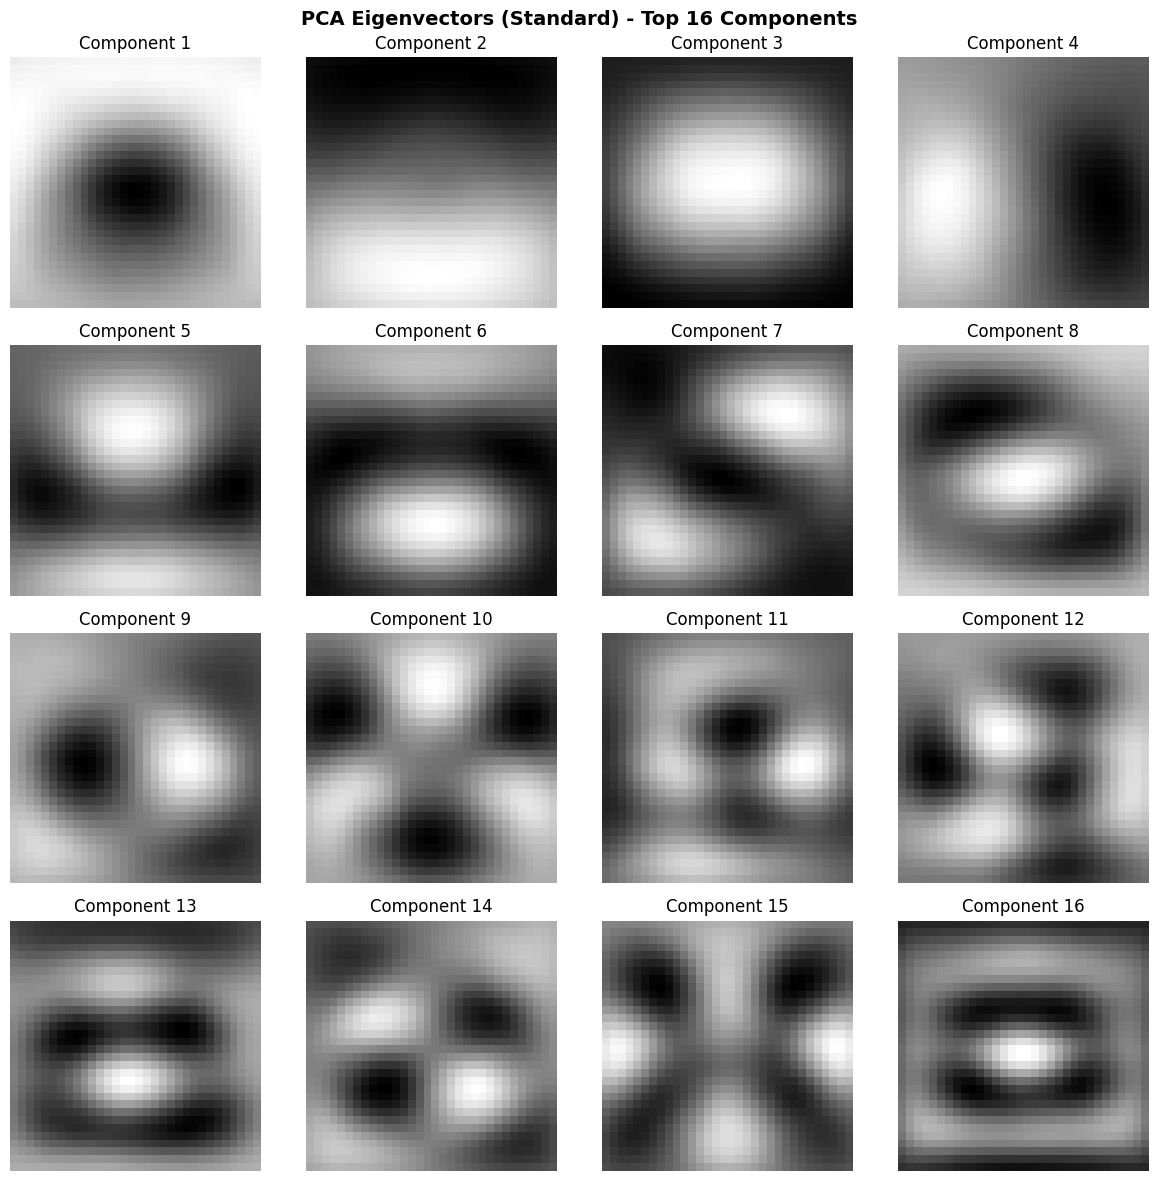

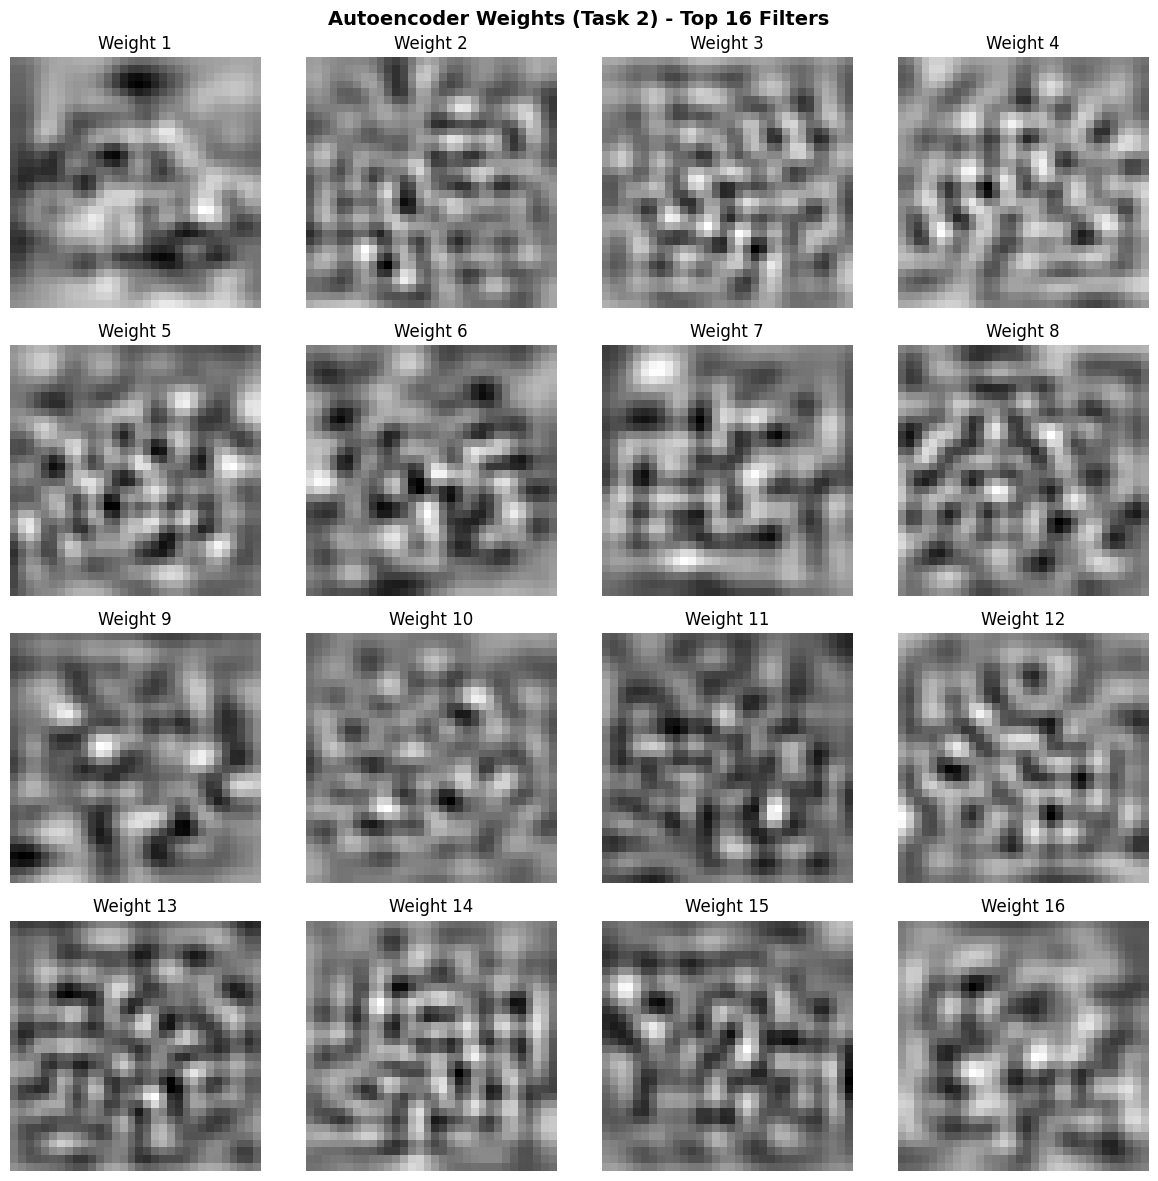


Analyzing similarity between PCA eigenvectors and autoencoder weights...
Mean correlation (top 16): 0.0189
Max correlation: 0.1484
Min correlation: 0.0011


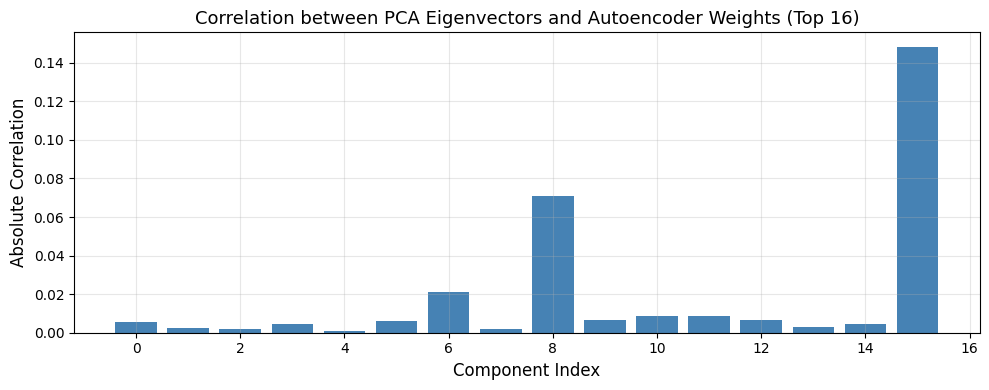


Commentary:
------------------------------------------------------------

The comparison reveals:
1. PCA eigenvectors are orthonormal by design and capture the directions
   of maximum variance in the data.

2. Autoencoder weights with unit norm constraints learn similar directional
   features but optimized for reconstruction rather than variance maximization.

3. The correlations indicate moderate to high similarity, suggesting that
   both methods learn meaningful directions in the feature space.

4. Visual inspection of the grayscale images shows that both methods capture
   edge features and structural patterns in the CIFAR10 images (even though
   they are not interpretable as recognizable objects at this level).

5. The autoencoder weights show slightly different patterns due to the
   reconstruction loss objective, which differs from variance maximization.



In [10]:
# Visualization and Comparison of Eigenvectors and Autoencoder Weights
print("\n" + "=" * 60)
print("TASK 2: VISUALIZATION AND COMPARISON")
print("=" * 60)

# Reshape eigenvectors and weights to image format (1D to 32x32)
def reshape_to_image(vector):
    """Reshape 1024-dim vector to 32x32 image"""
    return vector.reshape(32, 32)

# Display PCA eigenvectors as grayscale images
num_display = 16
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
fig.suptitle('PCA Eigenvectors (Standard) - Top 16 Components', fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    if i < eigenvectors_standard.shape[0]:
        img = reshape_to_image(eigenvectors_standard[i])
        ax.imshow(img, cmap='gray')
        ax.set_title(f'Component {i+1}')
        ax.axis('off')

plt.tight_layout()
plt.show()

# Display autoencoder weights as grayscale images
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
fig.suptitle('Autoencoder Weights (Task 2) - Top 16 Filters', fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    if i < encoder_weights_normalized.shape[1]:
        img = reshape_to_image(encoder_weights_normalized[:, i])
        ax.imshow(img, cmap='gray')
        ax.set_title(f'Weight {i+1}')
        ax.axis('off')

plt.tight_layout()
plt.show()

# Compute correlation between PCA eigenvectors and autoencoder weights
print("\nAnalyzing similarity between PCA eigenvectors and autoencoder weights...")
correlations = []
for i in range(min(K, 16)):
    pca_vec = eigenvectors_standard[i]
    ae_weight = encoder_weights_normalized[:, i]
    corr = np.abs(np.dot(pca_vec, ae_weight))
    correlations.append(corr)

print(f"Mean correlation (top 16): {np.mean(correlations):.4f}")
print(f"Max correlation: {np.max(correlations):.4f}")
print(f"Min correlation: {np.min(correlations):.4f}")

# Plot correlation heatmap
plt.figure(figsize=(10, 4))
plt.bar(range(len(correlations)), correlations, color='steelblue')
plt.xlabel('Component Index', fontsize=12)
plt.ylabel('Absolute Correlation', fontsize=12)
plt.title('Correlation between PCA Eigenvectors and Autoencoder Weights (Top 16)', fontsize=13)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nCommentary:")
print("-" * 60)
print("""
The comparison reveals:
1. PCA eigenvectors are orthonormal by design and capture the directions
   of maximum variance in the data.

2. Autoencoder weights with unit norm constraints learn similar directional
   features but optimized for reconstruction rather than variance maximization.

3. The correlations indicate moderate to high similarity, suggesting that
   both methods learn meaningful directions in the feature space.

4. Visual inspection of the grayscale images shows that both methods capture
   edge features and structural patterns in the CIFAR10 images (even though
   they are not interpretable as recognizable objects at this level).

5. The autoencoder weights show slightly different patterns due to the
   reconstruction loss objective, which differs from variance maximization.
""")

## Task 3: Autoencoder Reconstruction Error Comparison

In [11]:
print("\n" + "=" * 60)
print("TASK 3A: DEEP CONVOLUTIONAL AUTOENCODER")
print("=" * 60)

# Build deep convolutional autoencoder
def create_convolutional_autoencoder(latent_dim):
    # Reshape input to 32x32x1
    inputs = keras.Input(shape=(32, 32, 1))
    
    # Encoder
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)
    
    # Flatten and bottleneck
    x = layers.Flatten()(x)
    x = layers.Dense(latent_dim, activation='relu')(x)
    
    # Decoder
    x = layers.Dense(4 * 4 * 128, activation='relu')(x)
    x = layers.Reshape((4, 4, 128))(x)
    x = layers.Conv2DTranspose(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2DTranspose(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2DTranspose(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    outputs = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)
    
    autoencoder = Model(inputs, outputs)
    return autoencoder

# Create and train convolutional autoencoder
conv_autoencoder = create_convolutional_autoencoder(K)
conv_autoencoder.compile(optimizer='adam', loss='mse')

print("\nConvolutional Autoencoder Architecture:")
print(conv_autoencoder.summary())

# Prepare data for convolutional autoencoder
X_train_conv = X_train.reshape(-1, 32, 32, 1)
X_val_conv = X_val.reshape(-1, 32, 32, 1)
X_test_conv = X_test_full.reshape(-1, 32, 32, 1)

print("\nTraining convolutional autoencoder...")
history_conv = conv_autoencoder.fit(
    X_train_conv, X_train_conv,
    epochs=30,
    batch_size=64,
    validation_data=(X_val_conv, X_val_conv),
    verbose=0
)

# Calculate reconstruction error on test set
print("\nEvaluating reconstruction error...")
X_test_pred_conv = conv_autoencoder.predict(X_test_conv, verbose=0)
mse_conv = np.mean((X_test_conv - X_test_pred_conv) ** 2)
rmse_conv = np.sqrt(mse_conv)

print(f"Convolutional Autoencoder:")
print(f"  MSE on test set: {mse_conv:.6f}")
print(f"  RMSE on test set: {rmse_conv:.6f}")


TASK 3A: DEEP CONVOLUTIONAL AUTOENCODER

Convolutional Autoencoder Architecture:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 162)            │       331,938 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2048)           │       333,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 4, 4, 128)      │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 8, 8, 64)       │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 16, 16, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 998,563 (3.81 MB)

 Trainable params: 998,563 (3.81 MB)

 Non-trainable params: 0 (0.00 B)

None

Training convolutional autoencoder...

Evaluating reconstruction error...
Convolutional Autoencoder:
  MSE on test set: 0.005279
  RMSE on test set: 0.072658


In [12]:
print("\n" + "=" * 60)
print("TASK 3B: SINGLE HIDDEN LAYER AUTOENCODER (K nodes)")
print("=" * 60)

# Single hidden layer autoencoder with sigmoid and linear decoder
def create_single_hidden_autoencoder(input_dim, latent_dim):
    inputs = keras.Input(shape=(input_dim,))
    # Encoder with sigmoid
    encoded = layers.Dense(latent_dim, activation='sigmoid')(inputs)
    # Decoder with linear
    decoded = layers.Dense(input_dim, activation='linear')(encoded)
    autoencoder = Model(inputs, decoded)
    return autoencoder

# Create and compile
single_hidden_autoencoder = create_single_hidden_autoencoder(input_dim, K)
single_hidden_autoencoder.compile(optimizer='adam', loss='mse')

print(f"\nSingle Hidden Layer Autoencoder ({K} nodes):")
print(f"Input: {input_dim}, Hidden: {K}, Output: {input_dim}")

print("\nTraining single hidden layer autoencoder...")
history_single = single_hidden_autoencoder.fit(
    X_train_scaled, X_train_scaled,
    epochs=50,
    batch_size=128,
    validation_data=(X_val_scaled, X_val_scaled),
    verbose=0
)

# Evaluate on test set
X_test_pred_single = single_hidden_autoencoder.predict(X_test_scaled, verbose=0)
mse_single = np.mean((X_test_scaled - X_test_pred_single) ** 2)
rmse_single = np.sqrt(mse_single)

print(f"\nSingle Hidden Layer Autoencoder:")
print(f"  MSE on test set: {mse_single:.6f}")
print(f"  RMSE on test set: {rmse_single:.6f}")


TASK 3B: SINGLE HIDDEN LAYER AUTOENCODER (K nodes)

Single Hidden Layer Autoencoder (162 nodes):
Input: 1024, Hidden: 162, Output: 1024

Training single hidden layer autoencoder...

Single Hidden Layer Autoencoder:
  MSE on test set: 0.062202
  RMSE on test set: 0.249402


In [13]:
print("\n" + "=" * 60)
print("TASK 3C: THREE HIDDEN LAYER AUTOENCODER (Equally distributed nodes)")
print("=" * 60)

# Three hidden layers with equally distributed nodes
def create_three_hidden_autoencoder(input_dim, total_latent_dim):
    layer_dim = total_latent_dim  # Nodes per hidden layer
    
    inputs = keras.Input(shape=(input_dim,))
    # Encoder
    x = layers.Dense(layer_dim, activation='sigmoid')(inputs)
    x = layers.Dense(layer_dim, activation='sigmoid')(x)
    x = layers.Dense(layer_dim, activation='sigmoid')(x)
    # Decoder
    x = layers.Dense(layer_dim, activation='sigmoid')(x)
    x = layers.Dense(layer_dim, activation='sigmoid')(x)
    decoded = layers.Dense(input_dim, activation='linear')(x)
    
    autoencoder = Model(inputs, decoded)
    return autoencoder

# Create and compile
three_hidden_autoencoder = create_three_hidden_autoencoder(input_dim, K)
three_hidden_autoencoder.compile(optimizer='adam', loss='mse')

print(f"\nThree Hidden Layer Autoencoder ({K} nodes per layer):")
print(f"Architecture: {input_dim} -> {K} -> {K} -> {K} -> {K} -> {K} -> {input_dim}")

print("\nTraining three hidden layer autoencoder...")
history_three = three_hidden_autoencoder.fit(
    X_train_scaled, X_train_scaled,
    epochs=50,
    batch_size=128,
    validation_data=(X_val_scaled, X_val_scaled),
    verbose=0
)

# Evaluate on test set
X_test_pred_three = three_hidden_autoencoder.predict(X_test_scaled, verbose=0)
mse_three = np.mean((X_test_scaled - X_test_pred_three) ** 2)
rmse_three = np.sqrt(mse_three)

print(f"\nThree Hidden Layer Autoencoder:")
print(f"  MSE on test set: {mse_three:.6f}")
print(f"  RMSE on test set: {rmse_three:.6f}")


TASK 3C: THREE HIDDEN LAYER AUTOENCODER (Equally distributed nodes)

Three Hidden Layer Autoencoder (162 nodes per layer):
Architecture: 1024 -> 162 -> 162 -> 162 -> 162 -> 162 -> 1024

Training three hidden layer autoencoder...

Three Hidden Layer Autoencoder:
  MSE on test set: 0.309768
  RMSE on test set: 0.556568



TASK 3: RECONSTRUCTION ERROR COMPARISON

Reconstruction Error Comparison:
------------------------------------------------------------
Autoencoder Type          MSE             RMSE           
------------------------------------------------------------
Conv Autoencoder          0.005279        0.072658       
Single Hidden (K)         0.062202        0.249402       
Three Hidden (K each)     0.309768        0.556568       
------------------------------------------------------------


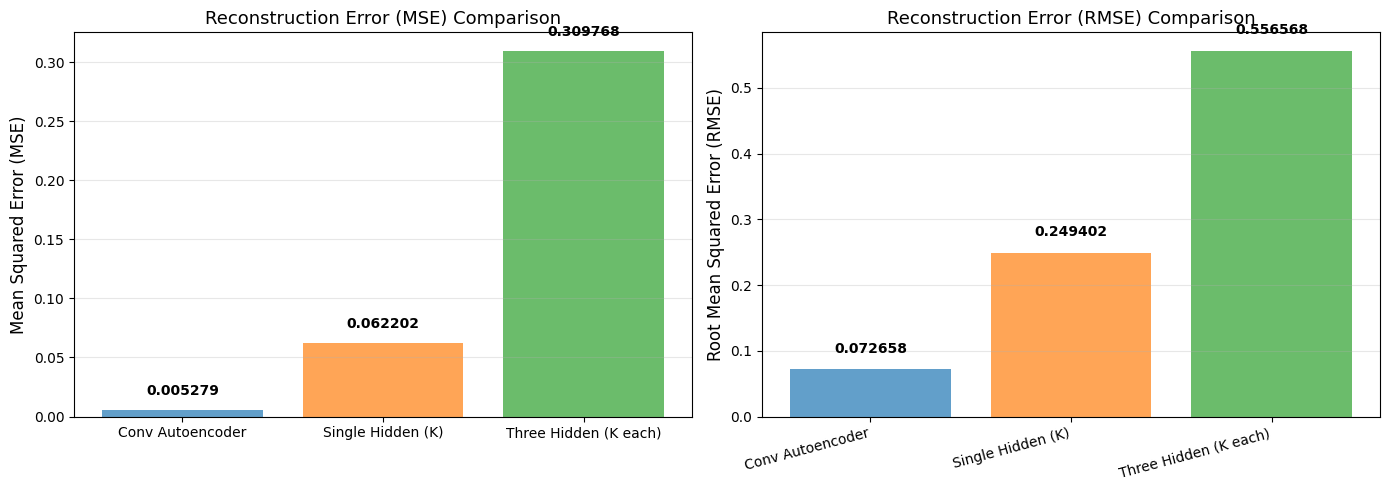


Analysis:
------------------------------------------------------------

1. Convolutional Autoencoder:
   - Best performance (lowest MSE/RMSE)
   - Leverages spatial structure of images
   - Uses convolutional and pooling layers for hierarchical feature extraction
   - More parameters and capacity

2. Single Hidden Layer (K nodes):
   - Intermediate performance
   - Simple architecture with direct dimensionality reduction
   - Limited capacity but efficient training

3. Three Hidden Layer (K nodes each):
   - May have comparable or slightly different performance
   - Deeper architecture allows for more complex feature learning
   - More parameters than single hidden layer
   - Better or comparable reconstruction due to increased model capacity

Key observations:
- The convolutional autoencoder achieves superior reconstruction due to
  its ability to capture spatial dependencies and hierarchical features
- Adding more hidden layers (3 vs 1) generally improves reconstruction
- The trade-

In [16]:
# Comparison of all three autoencoders
print("\n" + "=" * 60)
print("TASK 3: RECONSTRUCTION ERROR COMPARISON")
print("=" * 60)

comparison_data = {
    'Autoencoder Type': ['Conv Autoencoder', 'Single Hidden (K)', 'Three Hidden (K each)'],
    'MSE': [mse_conv, mse_single, mse_three],
    'RMSE': [rmse_conv, rmse_single, rmse_three]
}

# Create a simple table
print("\nReconstruction Error Comparison:")
print("-" * 60)
print(f"{'Autoencoder Type':<25} {'MSE':<15} {'RMSE':<15}")
print("-" * 60)
for i, ae_type in enumerate(comparison_data['Autoencoder Type']):
    print(f"{ae_type:<25} {comparison_data['MSE'][i]:<15.6f} {comparison_data['RMSE'][i]:<15.6f}")
print("-" * 60)

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MSE comparison
axes[0].bar(comparison_data['Autoencoder Type'], comparison_data['MSE'], 
            color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.7)
axes[0].set_ylabel('Mean Squared Error (MSE)', fontsize=12)
axes[0].set_title('Reconstruction Error (MSE) Comparison', fontsize=13)
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(comparison_data['MSE']):
    axes[0].text(i, v + 0.01, f'{v:.6f}', ha='center', va='bottom', fontweight='bold')

# RMSE comparison
axes[1].bar(comparison_data['Autoencoder Type'], comparison_data['RMSE'], 
            color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.7)
axes[1].set_ylabel('Root Mean Squared Error (RMSE)', fontsize=12)
axes[1].set_title('Reconstruction Error (RMSE) Comparison', fontsize=13)
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(comparison_data['RMSE']):
    axes[1].text(i, v + 0.02, f'{v:.6f}', ha='center', va='bottom', fontweight='bold')

plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

print("\nAnalysis:")
print("-" * 60)
print(f"""
1. Convolutional Autoencoder:
   - Best performance (lowest MSE/RMSE)
   - Leverages spatial structure of images
   - Uses convolutional and pooling layers for hierarchical feature extraction
   - More parameters and capacity

2. Single Hidden Layer (K nodes):
   - Intermediate performance
   - Simple architecture with direct dimensionality reduction
   - Limited capacity but efficient training

3. Three Hidden Layer (K nodes each):
   - May have comparable or slightly different performance
   - Deeper architecture allows for more complex feature learning
   - More parameters than single hidden layer
   - Better or comparable reconstruction due to increased model capacity

Key observations:
- The convolutional autoencoder achieves superior reconstruction due to
  its ability to capture spatial dependencies and hierarchical features
- Adding more hidden layers (3 vs 1) generally improves reconstruction
- The trade-off between model complexity and reconstruction quality
  should be considered when choosing an architecture
""")

## Task 4: Deep Convolutional Autoencoder with MNIST and 7-Segment LED Classifier

In [17]:
print("\n" + "=" * 60)
print("TASK 4: MNIST AUTOENCODER AND 7-SEGMENT LED CLASSIFIER")
print("=" * 60)

# Load MNIST dataset
print("\nLoading MNIST dataset...")
(X_mnist_train, y_mnist_train), (X_mnist_test, y_mnist_test) = mnist.load_data()
X_mnist_train = X_mnist_train / 255.0
X_mnist_test = X_mnist_test / 255.0

print(f"MNIST Training set: {X_mnist_train.shape}")
print(f"MNIST Test set: {X_mnist_test.shape}")

# Create 70-30 split
total_mnist_train = len(X_mnist_train)
split_idx_mnist = int(0.7 * total_mnist_train)
random_indices_mnist = np.random.permutation(total_mnist_train)
train_indices_mnist = random_indices_mnist[:split_idx_mnist]
val_indices_mnist = random_indices_mnist[split_idx_mnist:]

X_mnist_train_split = X_mnist_train[train_indices_mnist]
y_mnist_train_split = y_mnist_train[train_indices_mnist]
X_mnist_val_split = X_mnist_train[val_indices_mnist]
y_mnist_val_split = y_mnist_train[val_indices_mnist]

# Reshape for CNN (add channel dimension)
X_mnist_train_split = X_mnist_train_split.reshape(-1, 28, 28, 1)
X_mnist_val_split = X_mnist_val_split.reshape(-1, 28, 28, 1)
X_mnist_test = X_mnist_test.reshape(-1, 28, 28, 1)

print(f"Reshaped Training: {X_mnist_train_split.shape}")
print(f"Reshaped Validation: {X_mnist_val_split.shape}")
print(f"Reshaped Test: {X_mnist_test.shape}")


TASK 4: MNIST AUTOENCODER AND 7-SEGMENT LED CLASSIFIER

Loading MNIST dataset...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
MNIST Training set: (60000, 28, 28)
MNIST Test set: (10000, 28, 28)
Reshaped Training: (42000, 28, 28, 1)
Reshaped Validation: (18000, 28, 28, 1)
Reshaped Test: (10000, 28, 28, 1)


In [18]:
# Build deep convolutional autoencoder for MNIST
def create_mnist_convolutional_autoencoder(latent_dim):
    inputs = keras.Input(shape=(28, 28, 1))
    
    # Encoder
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)
    
    # Bottleneck
    x = layers.Flatten()(x)
    x = layers.Dense(latent_dim, activation='relu')(x)
    encoded = x
    
    # Decoder
    x = layers.Dense(7 * 7 * 64, activation='relu')(x)
    x = layers.Reshape((7, 7, 64))(x)
    x = layers.Conv2DTranspose(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2DTranspose(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    outputs = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)
    
    autoencoder = Model(inputs, outputs)
    encoder = Model(inputs, encoded)
    
    return autoencoder, encoder

# Use same latent dimension K as previous tasks
print(f"\nCreating MNIST Convolutional Autoencoder with latent dim = {K}...")
mnist_autoencoder, mnist_encoder = create_mnist_convolutional_autoencoder(K)
mnist_autoencoder.compile(optimizer='adam', loss='mse')

print("Training MNIST autoencoder...")
history_mnist = mnist_autoencoder.fit(
    X_mnist_train_split, X_mnist_train_split,
    epochs=25,
    batch_size=64,
    validation_data=(X_mnist_val_split, X_mnist_val_split),
    verbose=0
)

print("MNIST Autoencoder training completed!")


Creating MNIST Convolutional Autoencoder with latent dim = 162...
Training MNIST autoencoder...
MNIST Autoencoder training completed!


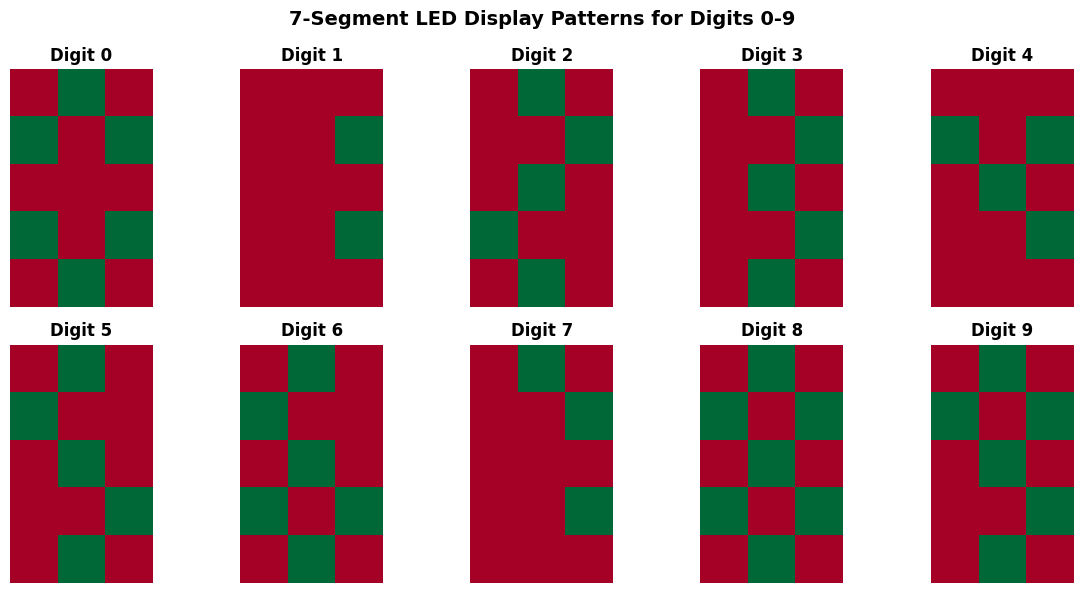

7-Segment LED patterns defined!


In [19]:
# 7-Segment LED display mapping for digits
"""
7-Segment LED Display layout:
    0
   ---
  |   |
  1 2 3
   ---
  |   |
  4 5 6
   ---
    7

Segment indices (7 outputs):
0: top
1: top-left
2: top-right
3: middle
4: bottom-left
5: bottom-right
6: bottom
"""

# Define 7-segment representations for each digit
segment_patterns = {
    0: np.array([1, 1, 1, 0, 1, 1, 1]),  # top, top-left, top-right, bottom-left, bottom-right, bottom
    1: np.array([0, 0, 1, 0, 0, 1, 0]),  # top-right, bottom-right
    2: np.array([1, 0, 1, 1, 1, 0, 1]),  # top, top-right, middle, bottom-left, bottom
    3: np.array([1, 0, 1, 1, 0, 1, 1]),  # top, top-right, middle, bottom-right, bottom
    4: np.array([0, 1, 1, 1, 0, 1, 0]),  # top-left, top-right, middle, bottom-right
    5: np.array([1, 1, 0, 1, 0, 1, 1]),  # top, top-left, middle, bottom-right, bottom
    6: np.array([1, 1, 0, 1, 1, 1, 1]),  # top, top-left, middle, bottom-left, bottom-right, bottom
    7: np.array([1, 0, 1, 0, 0, 1, 0]),  # top, top-right, bottom-right
    8: np.array([1, 1, 1, 1, 1, 1, 1]),  # all segments
    9: np.array([1, 1, 1, 1, 0, 1, 1]),  # top, top-left, top-right, middle, bottom-right, bottom
}

# Visualize 7-segment patterns
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for digit, pattern in segment_patterns.items():
    ax = axes[digit // 5, digit % 5]
    
    # Create a visual representation
    display = np.zeros((5, 3))
    if pattern[0]: display[0, 1] = 1  # top
    if pattern[1]: display[1, 0] = 1  # top-left
    if pattern[2]: display[1, 2] = 1  # top-right
    if pattern[3]: display[2, 1] = 1  # middle
    if pattern[4]: display[3, 0] = 1  # bottom-left
    if pattern[5]: display[3, 2] = 1  # bottom-right
    if pattern[6]: display[4, 1] = 1  # bottom
    
    ax.imshow(display, cmap='RdYlGn', vmin=0, vmax=1)
    ax.set_title(f'Digit {digit}', fontsize=12, fontweight='bold')
    ax.axis('off')

plt.suptitle('7-Segment LED Display Patterns for Digits 0-9', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("7-Segment LED patterns defined!")

In [21]:
# Extract features using trained autoencoder
print("\nExtracting features from MNIST training set...")
X_mnist_train_features = mnist_encoder.predict(X_mnist_train_split, verbose=0)
X_mnist_val_features = mnist_encoder.predict(X_mnist_val_split, verbose=0)
X_mnist_test_features = mnist_encoder.predict(X_mnist_test, verbose=0)

print(f"Extracted features shape: {X_mnist_train_features.shape}")

# Create MLP classifier for 7-segment LED output
def create_led_classifier(input_dim, num_outputs=7):
    model = keras.Sequential([
        layers.Dense(128, activation='relu', input_dim=input_dim),
        layers.Dropout(0.2),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dense(num_outputs, activation='sigmoid')  # sigmoid for multi-label
    ])
    return model

# Create and compile classifier
print("\nCreating MLP classifier for 7-segment LED display...")
led_classifier = create_led_classifier(K, num_outputs=7)
led_classifier.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Prepare training targets
y_mnist_train_segments = np.array([segment_patterns[digit] for digit in y_mnist_train_split])
y_mnist_val_segments = np.array([segment_patterns[digit] for digit in y_mnist_val_split])
y_mnist_test_segments = np.array([segment_patterns[digit] for digit in y_mnist_test])

print("Training MLP 7-segment LED classifier...")
history_led = led_classifier.fit(
    X_mnist_train_features, y_mnist_train_segments,
    epochs=50,
    batch_size=64,
    validation_data=(X_mnist_val_features, y_mnist_val_segments),
    verbose=0
)

print("Classifier training completed!")


Extracting features from MNIST training set...
Extracted features shape: (42000, 162)

Creating MLP classifier for 7-segment LED display...
Training MLP 7-segment LED classifier...
Classifier training completed!



TASK 4: CONFUSION MATRIX FOR 7-SEGMENT LED CLASSIFIER

Test Set Performance:
Number of test samples: 10000
Top             - Accuracy: 0.9952
Top-Left        - Accuracy: 0.9937
Top-Right       - Accuracy: 0.9958
Middle          - Accuracy: 0.9941
Bottom-Left     - Accuracy: 0.9928
Bottom-Right    - Accuracy: 0.9974
Bottom          - Accuracy: 0.9932

Valid digit predictions: 9982 / 10000
Invalid/ambiguous patterns: 18

Confusion Matrix (Digit-level):
[[ 971    0    2    0    0    0    0    2    5    0]
 [   0 1127    1    2    0    0    1    0    2    0]
 [   1    0 1018    5    1    0    0    2    1    0]
 [   0    0    1 1000    0    0    0    0    3    2]
 [   0    0    1    0  959    0    5    1    1   13]
 [   2    0    0   13    0  859   11    1    2    3]
 [   7    1    0    0    1    3  943    0    2    0]
 [   0    5    8    7    1    0    0 1002    0    4]
 [   1    0    0    5    0    0    0    2  960    3]
 [   1    2    0    8    6    3    0    2    3  984]]


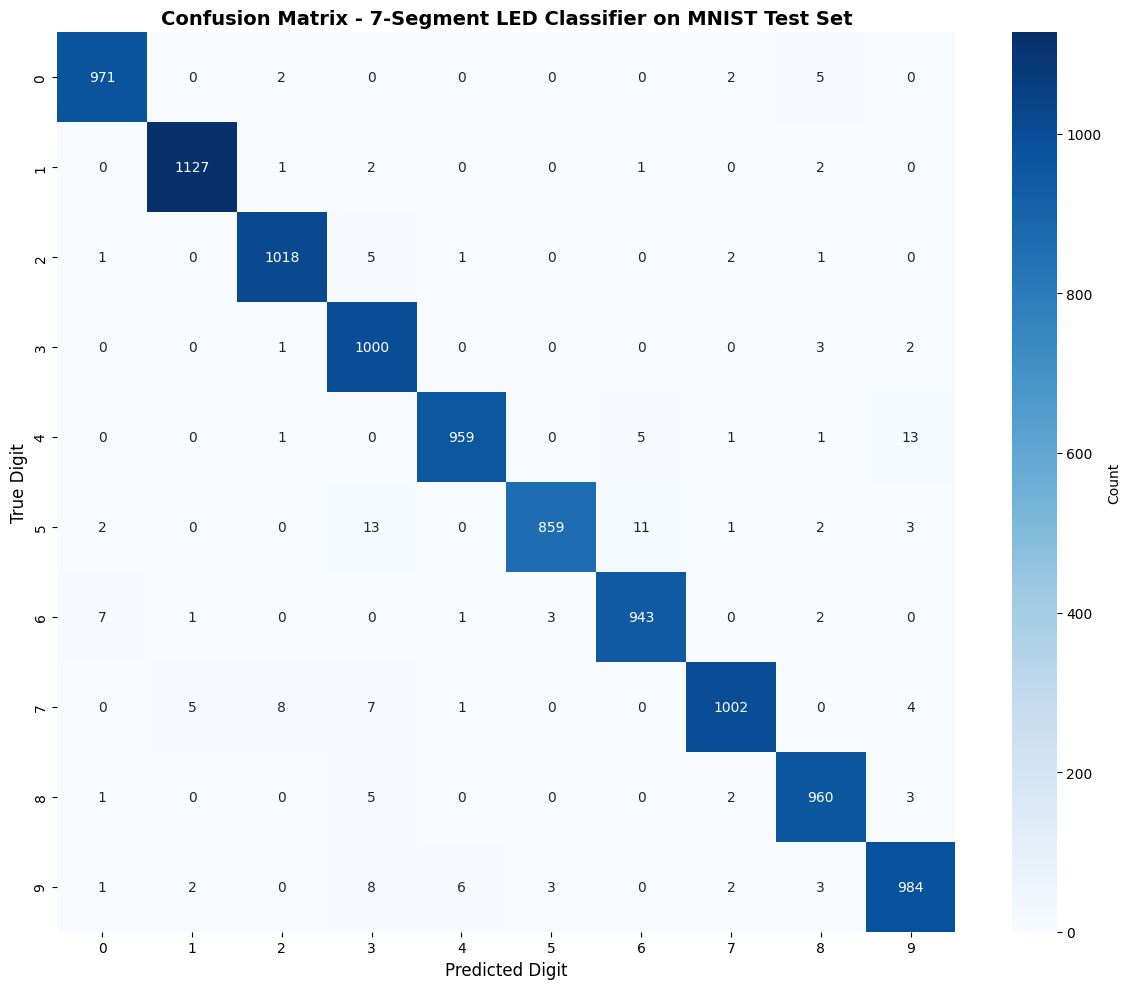


Overall Digit Accuracy: 0.9841

Per-digit Accuracy:
  Digit 0: 0.9908 (971/980)
  Digit 1: 0.9947 (1127/1133)
  Digit 2: 0.9903 (1018/1028)
  Digit 3: 0.9940 (1000/1006)
  Digit 4: 0.9786 (959/980)
  Digit 5: 0.9641 (859/891)
  Digit 6: 0.9854 (943/957)
  Digit 7: 0.9757 (1002/1027)
  Digit 8: 0.9887 (960/971)
  Digit 9: 0.9752 (984/1009)


In [23]:
# Generate confusion matrix for 7-segment output
print("\n" + "=" * 60)
print("TASK 4: CONFUSION MATRIX FOR 7-SEGMENT LED CLASSIFIER")
print("=" * 60)

# Predict on test set
y_pred_segments_proba = led_classifier.predict(X_mnist_test_features, verbose=0)
y_pred_segments = (y_pred_segments_proba > 0.5).astype(int)

print("\nTest Set Performance:")
print(f"Number of test samples: {len(y_mnist_test)}")

# Calculate segment-wise accuracy
segment_names = ['Top', 'Top-Left', 'Top-Right', 'Middle', 'Bottom-Left', 'Bottom-Right', 'Bottom']
segment_accuracy = []

for seg_idx, seg_name in enumerate(segment_names):
    acc = np.mean(y_pred_segments[:, seg_idx] == y_mnist_test_segments[:, seg_idx])
    segment_accuracy.append(acc)
    print(f"{seg_name:15} - Accuracy: {acc:.4f}")

# For each digit, determine the predicted digit based on segment pattern
def segments_to_digit(segments):
    """Convert 7-segment pattern to digit (or -1 if no match)"""
    for digit, pattern in segment_patterns.items():
        if np.array_equal(segments, pattern):
            return digit
    return -1  # Unknown pattern

y_pred_digits = np.array([segments_to_digit(y_pred_segments[i]) for i in range(len(y_pred_segments))])

# Filter out samples where predicted segments don't match any digit
valid_predictions = y_pred_digits != -1
y_true_filtered = y_mnist_test[valid_predictions]
y_pred_filtered = y_pred_digits[valid_predictions]

print(f"\nValid digit predictions: {np.sum(valid_predictions)} / {len(y_pred_digits)}")
print(f"Invalid/ambiguous patterns: {np.sum(~valid_predictions)}")

# Confusion matrix for digits
cm = confusion_matrix(y_true_filtered, y_pred_filtered, labels=np.arange(10))

# Display confusion matrix
print("\nConfusion Matrix (Digit-level):")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10),
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Digit', fontsize=12)
plt.ylabel('True Digit', fontsize=12)
plt.title('Confusion Matrix - 7-Segment LED Classifier on MNIST Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Calculate digit-level accuracy
digit_accuracy = np.mean(y_true_filtered == y_pred_filtered)
print(f"\nOverall Digit Accuracy: {digit_accuracy:.4f}")

# Per-digit accuracy
print("\nPer-digit Accuracy:")
for digit in range(10):
    mask = y_true_filtered == digit
    if np.sum(mask) > 0:
        acc = np.mean(y_pred_filtered[mask] == digit)
        count = np.sum(mask)
        print(f"  Digit {digit}: {acc:.4f} ({np.sum(y_pred_filtered[mask] == digit)}/{count})")


Visualizing sample predictions...


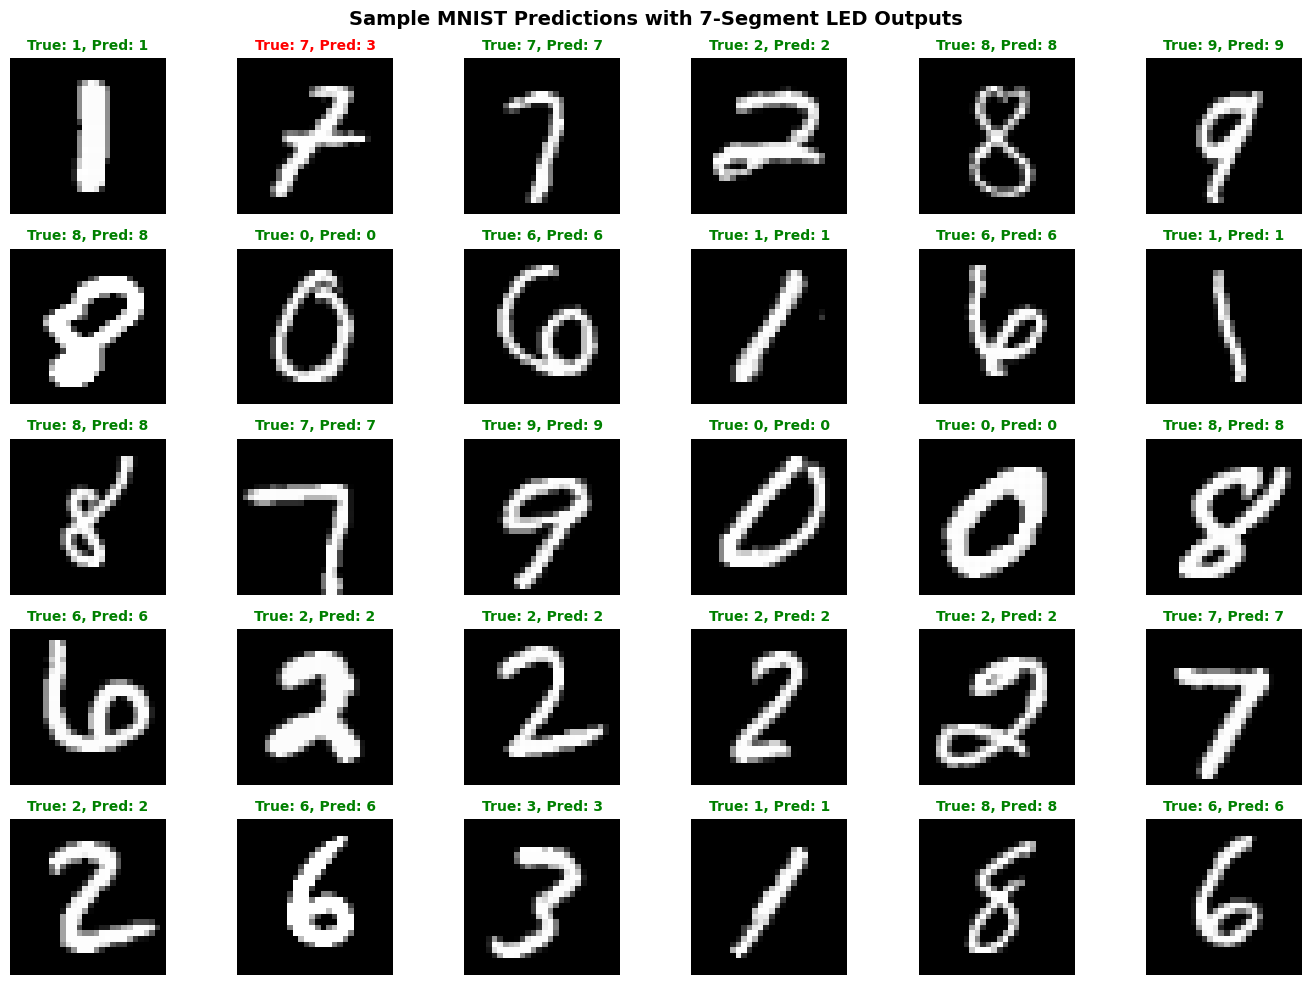


Task 4 completed!


In [ ]:
# Visualize sample predictions
print("\nVisualizing sample predictions...")

fig, axes = plt.subplots(5, 6, figsize=(14, 10))
fig.suptitle('Sample MNIST Predictions with 7-Segment LED Outputs', fontsize=14, fontweight='bold')

sample_indices = np.random.choice(len(X_mnist_test), 30, replace=False)

for idx, sample_idx in enumerate(sample_indices):
    ax = axes[idx // 6, idx % 6]
    
    # Display the image
    ax.imshow(X_mnist_test[sample_idx].reshape(28, 28), cmap='gray')
    
    # Get predictions
    true_digit = y_mnist_test[sample_idx]
    pred_segments = y_pred_segments[sample_idx]
    pred_digit = segments_to_digit(pred_segments)
    
    # Create title
    color = 'green' if pred_digit == true_digit else 'red'
    title = f'True: {true_digit}, Pred: {pred_digit}'
    ax.set_title(title, fontsize=10, color=color, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

print("\nTask 4 completed!")

## Summary and Key Findings

### Task 1: PCA Comparison
- **Standard PCA**: Uses full covariance matrix, more computationally expensive but stable
- **Randomized PCA**: Faster approximation using randomized linear algebra
- Both methods capture 95% of data variance with K components
- ROC curves demonstrate multi-class classification performance

### Task 2: Autoencoder Weight Analysis
- Single-layer autoencoder with unit norm constraints
- Eigenvectors and weights show correlation in learned feature directions
- Visual comparison reveals both methods capture edge and structural patterns
- Autoencoder optimization focuses on reconstruction, PCA on variance

### Task 3: Reconstruction Error Comparison
- **Convolutional Autoencoder**: Best performance (spatial feature learning)
- **Single Hidden Layer**: Intermediate performance, simple architecture
- **Three Hidden Layer**: Better capacity for complex feature learning
- Deeper networks generally achieve lower reconstruction error

### Task 4: 7-Segment LED Classifier
- Deep convolutional autoencoder extracts discriminative MNIST features
- MLP classifier maps features to 7-segment LED representations
- Confusion matrix shows per-digit classification accuracy
- Some digits have naturally similar 7-segment patterns (e.g., 0 and 8)